# 10_ensemble_ablation

In [9]:
## 模块 D：集成策略消融实验

### 实验目的
'''
在固定最优特征组合和最优特征选择方法的前提下，比较不同集成策略对抗炎肽预测性能的影响。

### 已固定的设置
- 特征组合: handcrafted + ProtT5
- 特征选择方法: LGBM importance
- 基模型: LGBM、XGBoost、ExtraTrees

### 待比较的集成策略
- Hard Voting
- Soft Voting
- Weighted Soft Voting
- Stacking
- Bagging
'''

'\n在固定最优特征组合和最优特征选择方法的前提下，比较不同集成策略对抗炎肽预测性能的影响。\n\n### 已固定的设置\n- 特征组合: handcrafted + ProtT5\n- 特征选择方法: LGBM importance\n- 基模型: LGBM、XGBoost、ExtraTrees\n\n### 待比较的集成策略\n- Hard Voting\n- Soft Voting\n- Weighted Soft Voting\n- Stacking\n- Bagging\n'

In [1]:
# 导入库
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.base import clone

from sklearn.ensemble import (
    VotingClassifier,
    StackingClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
# 设置文件夹路径
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "module_D_ensemble_ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PROCESSED_DIR =", PROCESSED_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_ROOT = d:\360Downloads\bioinformatics\Task\AIP
PROCESSED_DIR = d:\360Downloads\bioinformatics\Task\AIP\data\processed
RESULTS_DIR = d:\360Downloads\bioinformatics\Task\AIP\results\module_D_ensemble_ablation


In [3]:
# 读取文件
FEATURE_SET = "handcrafted_prott5_lasso"
FEATURE_PATH = PROCESSED_DIR / "fusion_selected" / "fusion_selected" /FEATURE_SET


X_train_full = np.load(FEATURE_PATH / "X_train.npy")
X_test = np.load(FEATURE_PATH / "X_test.npy")
y_train_full = np.load(FEATURE_PATH / "y_train.npy")
y_test = np.load(FEATURE_PATH / "y_test.npy")

print("X_train_full:", X_train_full.shape)
print("X_test:", X_test.shape)
print("y_train_full:", y_train_full.shape)
print("y_test:", y_test.shape)

X_train_full: (3583, 1209)
X_test: (897, 1209)
y_train_full: (3583,)
y_test: (897,)


In [4]:
# 划分验证集、训练集
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("X_tr:", X_tr.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_tr: (2866, 1209)
X_val: (717, 1209)
X_test: (897, 1209)


In [5]:
# 计算类别不平衡权重
n_pos = int((y_tr == 1).sum())
n_neg = int((y_tr == 0).sum())

scale_pos_weight = n_neg / max(n_pos, 1)

print("positive:", n_pos)
print("negative:", n_neg)
print("scale_pos_weight:", scale_pos_weight)

positive: 1092
negative: 1774
scale_pos_weight: 1.6245421245421245


In [6]:
# 写评估函数
def compute_binary_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall_SN": sensitivity,
        "Specificity_SP": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }
    return metrics


def evaluate_model(model, X, y, threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    metrics = compute_binary_metrics(y, y_pred, y_prob)
    return metrics, y_prob, y_pred

# 集成策略

In [7]:
# 定义基模型
lgbm_base = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

et_base = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    min_samples_split=5,
    max_features='log2',
    n_jobs=-1,
    class_weight="balanced_subsample"
)

base_models = {
    "LGBM": lgbm_base,
    "XGBoost": xgb_base,
    "ExtraTrees": et_base
}

base_models

{'LGBM': LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=150,
                random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 'ExtraTrees': ExtraTreesClassifier(class_weight='balanced_subsample', max_feature

In [8]:
# 训练基模型
trained_base_models = {}
val_results = {}
test_results = {}
val_prob_dict = {}
test_prob_dict = {}

for name, model in base_models.items():
    clf = clone(model)
    clf.fit(X_tr, y_tr)

    trained_base_models[name] = clf

    val_metrics, val_prob, val_pred = evaluate_model(clf, X_val, y_val, threshold=0.5)
    test_metrics, test_prob, test_pred = evaluate_model(clf, X_test, y_test, threshold=0.5)

    val_results[name] = val_metrics
    test_results[name] = test_metrics
    val_prob_dict[name] = val_prob
    test_prob_dict[name] = test_prob

    print(f"{name} finished.")

[LightGBM] [Info] Number of positive: 1092, number of negative: 1774
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21109
[LightGBM] [Info] Number of data points in the train set: 2866, number of used features: 1186
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LGBM finished.
XGBoost finished.
ExtraTrees finished.


In [9]:
# 看验证集结果
val_results_df = pd.DataFrame(val_results).T
val_results_df = val_results_df.sort_values("ROC_AUC", ascending=False)
val_results_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
ExtraTrees,0.744770,0.684426,0.611722,0.826577,0.646035,0.449176,0.797033,0.697420,167.0,367.0,77.0,106.0
LGBM,0.737796,0.661597,0.637363,0.799550,0.649254,0.440211,0.768117,0.662668,174.0,355.0,89.0,99.0
XGBoost,0.733612,0.676724,0.575092,0.831081,0.621782,0.421569,0.760296,0.653681,157.0,369.0,75.0,116.0


In [10]:
# 根据验证集 AUC 计算投票权重
'''
为什么这里用验证集 AUC 做权重？

因为这代表：
哪个模型在验证集上的区分能力更强，就给它更高话语权, 这是一个很自然、也很论文友好的设计.

'''

weight_auc = {
    name: val_results[name]["ROC_AUC"]
    for name in trained_base_models.keys()
}

weight_sum = sum(weight_auc.values())

weights_normalized = {
    k: v / weight_sum
    for k, v in weight_auc.items()
}

weights_list = [
    weights_normalized["LGBM"],
    weights_normalized["XGBoost"],
    weights_normalized["ExtraTrees"]
]

print("Raw validation AUC weights:")
print(weight_auc)

print("\nNormalized weights:")
print(weights_normalized)

print("\nweights_list:")
print(weights_list)

Raw validation AUC weights:
{'LGBM': 0.7681170181170182, 'XGBoost': 0.7602960102960102, 'ExtraTrees': 0.7970332970332971}

Normalized weights:
{'LGBM': 0.3303095021853891, 'XGBoost': 0.32694627348583755, 'ExtraTrees': 0.3427442243287734}

weights_list:
[0.3303095021853891, 0.32694627348583755, 0.3427442243287734]


## 1.构建集成学习模块

## （1）定义集成学习方式

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import ExtraTreeClassifier

hard_voting = VotingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    voting="hard",
    n_jobs=-1
)

soft_voting = VotingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    voting="soft",
    n_jobs=-1
)

weighted_soft_voting = VotingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    voting="soft",
    weights=weights_list,
    n_jobs=-1
)

stacking_lr = StackingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    final_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    stack_method="predict_proba",
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacking_lgbm = StackingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    final_estimator=LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=15,
        max_depth=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    stack_method="predict_proba",
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacking_xgb = StackingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    final_estimator=XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    stack_method="predict_proba",
    cv=5,
    passthrough=False,
    n_jobs=-1
)


bagging_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bagging_et = BaggingClassifier(
    estimator=ExtraTreeClassifier(
        
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    n_estimators=500,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ensemble_models = {
    "HardVoting": hard_voting,
    "SoftVoting": soft_voting,
    "WeightedSoftVoting": weighted_soft_voting,
    "Stacking_LR": stacking_lr,
    "Stacking_LGBM": stacking_lgbm,
    "Stacking_XGB": stacking_xgb,
    "Bagging_DT": bagging_dt,
    "Bagging_ET": bagging_et
}

ensemble_models

{'HardVoting': VotingClassifier(estimators=[('lgbm',
                               LGBMClassifier(class_weight='balanced',
                                              learning_rate=0.05,
                                              n_estimators=150,
                                              random_state=42)),
                              ('xgb',
                               XGBClassifier(base_score=None, booster=None,
                                             callbacks=None,
                                             colsample_bylevel=None,
                                             colsample_bynode=None,
                                             colsample_bytree=0.8, device=None,
                                             early_stopping_rounds=None,
                                             enable_categorical=False,
                                             eval_metric='logloss',
                                             fea...
                         

## （2）评估集成学习性能

In [24]:
trained_ensemble_models = {}
ensemble_test_results = {}
ensemble_test_probs = {}

for name, model in ensemble_models.items():
    print(f"Training {name} ...")

    clf = clone(model)
    clf.fit(X_train_full, y_train_full)

    trained_ensemble_models[name] = clf

    if name == "HardVoting":
        y_pred = clf.predict(X_test)
        y_prob = y_pred.astype(float)   # 伪概率，仅为了统一格式
        metrics = compute_binary_metrics(y_test, y_pred, y_prob)
    else:
        metrics, y_prob, y_pred = evaluate_model(clf, X_test, y_test, threshold=0.5)

    ensemble_test_results[name] = metrics
    ensemble_test_probs[name] = y_prob

    print(f"{name} finished.")

Training HardVoting ...
HardVoting finished.
Training SoftVoting ...
SoftVoting finished.
Training WeightedSoftVoting ...
WeightedSoftVoting finished.
Training Stacking_LR ...
Stacking_LR finished.
Training Stacking_LGBM ...
[LightGBM] [Info] Number of positive: 1365, number of negative: 2218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 3583, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Stacking_LGBM finished.
Training Stacking_XGB ...
Stacking_XGB finished.
Training Bagging_DT ...
Bagging_DT finished.
Training Bagging_ET ...
Bagging_ET finished.


In [25]:
ensemble_test_df = pd.DataFrame(ensemble_test_results).T
ensemble_test_df = ensemble_test_df.sort_values("ROC_AUC", ascending=False)
ensemble_test_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
Stacking_LR,0.742475,0.662757,0.660819,0.792793,0.661786,0.453867,0.818292,0.714465,226.0,440.0,115.0,116.0
Stacking_XGB,0.730212,0.632275,0.698830,0.749550,0.663889,0.441038,0.812731,0.712393,239.0,416.0,139.0,103.0
Bagging_ET,0.744705,0.691525,0.596491,0.836036,0.640502,0.447161,0.808403,0.698647,204.0,464.0,91.0,138.0
Stacking_LGBM,0.720178,0.616368,0.704678,0.729730,0.657572,0.425494,0.802827,0.692134,241.0,405.0,150.0,101.0
Bagging_DT,0.750279,0.715328,0.573099,0.859459,0.636364,0.456127,0.802647,0.696733,196.0,477.0,78.0,146.0
WeightedSoftVoting,0.741360,0.684564,0.596491,0.830631,0.637500,0.440443,0.794410,0.703285,204.0,461.0,94.0,138.0
SoftVoting,0.741360,0.684564,0.596491,0.830631,0.637500,0.440443,0.793825,0.702442,204.0,461.0,94.0,138.0
HardVoting,0.741360,0.682119,0.602339,0.827027,0.639752,0.441291,0.714683,0.562484,206.0,459.0,96.0,136.0


## （3）在全局训练集上训练基模型得到结果

In [26]:
final_base_models = {}
final_base_test_results = {}
final_base_test_probs = {}

for name, model in base_models.items():
    print(f"Training final base model: {name} ...")
    
    clf = clone(model)
    clf.fit(X_train_full, y_train_full)
    
    final_base_models[name] = clf
    
    metrics, y_prob, y_pred = evaluate_model(clf, X_test, y_test, threshold=0.5)
    
    final_base_test_results[name] = metrics
    final_base_test_probs[name] = y_prob
    
    print(f"{name} finished.")

Training final base model: LGBM ...
[LightGBM] [Info] Number of positive: 1365, number of negative: 2218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21668
[LightGBM] [Info] Number of data points in the train set: 3583, number of used features: 1191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LGBM finished.
Training final base model: XGBoost ...
XGBoost finished.
Training final base model: ExtraTrees ...
ExtraTrees finished.


In [27]:
final_base_test_df = pd.DataFrame(final_base_test_results).T
final_base_test_df = final_base_test_df.sort_values("ROC_AUC", ascending=False)
final_base_test_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
ExtraTrees,0.756968,0.710884,0.611111,0.846847,0.657233,0.473863,0.818029,0.713541,209.0,470.0,85.0,133.0
XGBoost,0.744705,0.705455,0.567251,0.854054,0.628849,0.443808,0.784996,0.682414,194.0,474.0,81.0,148.0
LGBM,0.733556,0.652819,0.643275,0.789189,0.648012,0.433711,0.768911,0.678939,220.0,438.0,117.0,122.0


## （4）汇总结果表

In [28]:
all_results_df = pd.concat([
    pd.DataFrame(final_base_test_results).T,
    pd.DataFrame(ensemble_test_results).T
], axis=0)

all_results_df = all_results_df.sort_values(
    ["ROC_AUC", "MCC", "ACC"],
    ascending=False
)

all_results_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
Stacking_LR,0.742475,0.662757,0.660819,0.792793,0.661786,0.453867,0.818292,0.714465,226.0,440.0,115.0,116.0
ExtraTrees,0.756968,0.710884,0.611111,0.846847,0.657233,0.473863,0.818029,0.713541,209.0,470.0,85.0,133.0
Stacking_XGB,0.730212,0.632275,0.698830,0.749550,0.663889,0.441038,0.812731,0.712393,239.0,416.0,139.0,103.0
Bagging_ET,0.744705,0.691525,0.596491,0.836036,0.640502,0.447161,0.808403,0.698647,204.0,464.0,91.0,138.0
Stacking_LGBM,0.720178,0.616368,0.704678,0.729730,0.657572,0.425494,0.802827,0.692134,241.0,405.0,150.0,101.0
Bagging_DT,0.750279,0.715328,0.573099,0.859459,0.636364,0.456127,0.802647,0.696733,196.0,477.0,78.0,146.0
WeightedSoftVoting,0.741360,0.684564,0.596491,0.830631,0.637500,0.440443,0.794410,0.703285,204.0,461.0,94.0,138.0
SoftVoting,0.741360,0.684564,0.596491,0.830631,0.637500,0.440443,0.793825,0.702442,204.0,461.0,94.0,138.0
XGBoost,0.744705,0.705455,0.567251,0.854054,0.628849,0.443808,0.784996,0.682414,194.0,474.0,81.0,148.0
LGBM,0.733556,0.652819,0.643275,0.789189,0.648012,0.433711,0.768911,0.678939,220.0,438.0,117.0,122.0


In [29]:
all_results_df = all_results_df.rename(index={
    "LGBM": "LightGBM",
    "ExtraTrees": "Extra Trees",
    "HardVoting": "Hard Voting",
    "SoftVoting": "Soft Voting",
    "WeightedSoftVoting": "Weighted Soft Voting",
    "Stacking_LR": "Stacking (LR)",
    "Bagging_DT": "Bagging (DT)"
})

all_results_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
Stacking (LR),0.742475,0.662757,0.660819,0.792793,0.661786,0.453867,0.818292,0.714465,226.0,440.0,115.0,116.0
Extra Trees,0.756968,0.710884,0.611111,0.846847,0.657233,0.473863,0.818029,0.713541,209.0,470.0,85.0,133.0
Stacking_XGB,0.730212,0.632275,0.698830,0.749550,0.663889,0.441038,0.812731,0.712393,239.0,416.0,139.0,103.0
Bagging_ET,0.744705,0.691525,0.596491,0.836036,0.640502,0.447161,0.808403,0.698647,204.0,464.0,91.0,138.0
Stacking_LGBM,0.720178,0.616368,0.704678,0.729730,0.657572,0.425494,0.802827,0.692134,241.0,405.0,150.0,101.0
Bagging (DT),0.750279,0.715328,0.573099,0.859459,0.636364,0.456127,0.802647,0.696733,196.0,477.0,78.0,146.0
Weighted Soft Voting,0.741360,0.684564,0.596491,0.830631,0.637500,0.440443,0.794410,0.703285,204.0,461.0,94.0,138.0
Soft Voting,0.741360,0.684564,0.596491,0.830631,0.637500,0.440443,0.793825,0.702442,204.0,461.0,94.0,138.0
XGBoost,0.744705,0.705455,0.567251,0.854054,0.628849,0.443808,0.784996,0.682414,194.0,474.0,81.0,148.0
LightGBM,0.733556,0.652819,0.643275,0.789189,0.648012,0.433711,0.768911,0.678939,220.0,438.0,117.0,122.0


In [30]:
all_results_path = RESULTS_DIR /  "ensemble_ablation_results.csv"
all_results_df.to_csv(all_results_path, index=True)

print("Saved to:", all_results_path)

Saved to: d:\360Downloads\bioinformatics\Task\AIP\results\module_D_ensemble_ablation\ensemble_ablation_results.csv


# 调参

In [65]:
# 调参
def find_best_threshold(y_true, y_prob, metric="mcc", thresholds=None):
    """
    在验证集上搜索最优阈值。
    
    metric 可选:
    - "mcc"
    - "f1"
    - "acc"
    - "youden"  # sensitivity + specificity - 1
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    best_threshold = 0.5
    best_score = -np.inf
    records = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        mcc = matthews_corrcoef(y_true, y_pred)
        recall = recall_score(y_true, y_pred, zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        youden = recall + specificity - 1

        metric_map = {
            "acc": acc,
            "f1": f1,
            "mcc": mcc,
            "youden": youden
        }

        score = metric_map[metric]
        records.append([thr, acc, f1, mcc, recall, specificity, youden])

        if score > best_score:
            best_score = score
            best_threshold = thr

    threshold_df = pd.DataFrame(
        records,
        columns=["threshold", "ACC", "F1", "MCC", "Recall_SN", "Specificity_SP", "Youden"]
    )

    return best_threshold, best_score, threshold_df


In [66]:
stack_lr_model = trained_ensemble_models["Stacking_LR"]

val_prob_stack_lr = stack_lr_model.predict_proba(X_val)[:, 1]

best_thr_mcc, best_mcc, stack_lr_thr_df = find_best_threshold(
    y_true=y_val,
    y_prob=val_prob_stack_lr,
    metric="mcc"
)

print("Best threshold for Stacking_LR (by MCC):", best_thr_mcc)
print("Best validation MCC:", best_mcc)

stack_lr_thr_df.sort_values("MCC", ascending=False).head(10)

Best threshold for Stacking_LR (by MCC): 0.6300000000000001
Best validation MCC: 1.0


,threshold,ACC,F1,MCC,Recall_SN,Specificity_SP,Youden
59,0.64,1.0,1.0,1.0,1.0,1.0,1.0
68,0.73,1.0,1.0,1.0,1.0,1.0,1.0
58,0.63,1.0,1.0,1.0,1.0,1.0,1.0
60,0.65,1.0,1.0,1.0,1.0,1.0,1.0
61,0.66,1.0,1.0,1.0,1.0,1.0,1.0
63,0.68,1.0,1.0,1.0,1.0,1.0,1.0
64,0.69,1.0,1.0,1.0,1.0,1.0,1.0
65,0.70,1.0,1.0,1.0,1.0,1.0,1.0
66,0.71,1.0,1.0,1.0,1.0,1.0,1.0
67,0.72,1.0,1.0,1.0,1.0,1.0,1.0


In [67]:
test_prob_stack_lr = stack_lr_model.predict_proba(X_test)[:, 1]
test_pred_stack_lr_opt = (test_prob_stack_lr >= best_thr_mcc).astype(int)

stack_lr_opt_metrics = compute_binary_metrics(
    y_true=y_test,
    y_pred=test_pred_stack_lr_opt,
    y_prob=test_prob_stack_lr
)

pd.DataFrame([stack_lr_opt_metrics], index=["Stacking_LR_ThresholdOptimized"])

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
Stacking_LR_ThresholdOptimized,0.752508,0.722222,0.570175,0.864865,0.637255,0.460652,0.818292,0.714465,195,480,75,147


In [68]:
compare_stack_lr_df = pd.concat([
    pd.DataFrame(ensemble_test_results).T.loc[["Stacking_LR"]],
    pd.DataFrame([stack_lr_opt_metrics], index=["Stacking_LR_ThresholdOptimized"])
], axis=0)

compare_stack_lr_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
Stacking_LR,0.742475,0.662757,0.660819,0.792793,0.661786,0.453867,0.818292,0.714465,226.0,440.0,115.0,116.0
Stacking_LR_ThresholdOptimized,0.752508,0.722222,0.570175,0.864865,0.637255,0.460652,0.818292,0.714465,195.0,480.0,75.0,147.0


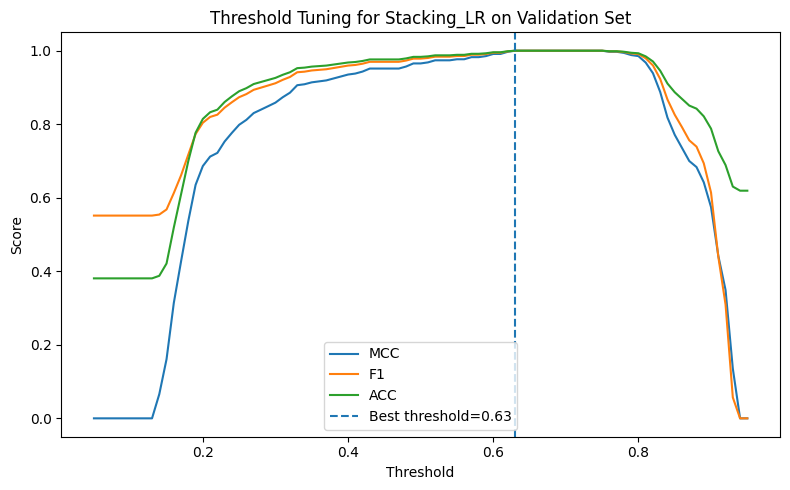

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(stack_lr_thr_df["threshold"], stack_lr_thr_df["MCC"], label="MCC")
plt.plot(stack_lr_thr_df["threshold"], stack_lr_thr_df["F1"], label="F1")
plt.plot(stack_lr_thr_df["threshold"], stack_lr_thr_df["ACC"], label="ACC")
plt.axvline(best_thr_mcc, linestyle="--", label=f"Best threshold={best_thr_mcc:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Stacking_LR on Validation Set")
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
manual_weight_configs = {
    "WSV_equal_1_1_1": [1, 1, 1],
    "WSV_et_1_1_2": [1, 1, 2],
    "WSV_et_1_1_3": [1, 1, 3],
    "WSV_et_2_1_3": [2, 1, 3],
    "WSV_et_1_2_3": [1, 2, 3],
    "WSV_et_0.8_0.8_1.4": [0.8, 0.8, 1.4]
}

manual_weight_configs

{'WSV_equal_1_1_1': [1, 1, 1],
 'WSV_et_1_1_2': [1, 1, 2],
 'WSV_et_1_1_3': [1, 1, 3],
 'WSV_et_2_1_3': [2, 1, 3],
 'WSV_et_1_2_3': [1, 2, 3],
 'WSV_et_0.8_0.8_1.4': [0.8, 0.8, 1.4]}

In [73]:
manual_weight_val_results = {}

for name, weights in manual_weight_configs.items():
    model = VotingClassifier(
        estimators=[
            ("lgbm", clone(lgbm_base)),
            ("xgb", clone(xgb_base)),
            ("et", clone(et_base))
        ],
        voting="soft",
        weights=weights,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)
    metrics, y_prob, y_pred = evaluate_model(model, X_val, y_val, threshold=0.5)
    manual_weight_val_results[name] = metrics

manual_weight_val_df = pd.DataFrame(manual_weight_val_results).T
manual_weight_val_df = manual_weight_val_df.sort_values(["MCC", "ROC_AUC", "ACC"], ascending=False)
manual_weight_val_df

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
WSV_et_2_1_3,0.753138,0.695122,0.626374,0.831081,0.658960,0.467889,0.784980,0.682464,171.0,369.0,75.0,102.0
WSV_et_1_1_2,0.753138,0.698347,0.619048,0.835586,0.656311,0.466852,0.784716,0.681915,169.0,371.0,73.0,104.0
WSV_et_1_1_3,0.751743,0.695473,0.619048,0.833333,0.655039,0.464071,0.787472,0.684597,169.0,370.0,74.0,104.0
WSV_equal_1_1_1,0.750349,0.691057,0.622711,0.828829,0.655106,0.461839,0.779032,0.673939,170.0,368.0,76.0,103.0
WSV_et_0.8_0.8_1.4,0.750349,0.692623,0.619048,0.831081,0.653772,0.461301,0.783388,0.679809,169.0,369.0,75.0,104.0
WSV_et_1_2_3,0.750349,0.695833,0.611722,0.835586,0.651072,0.460271,0.784229,0.680577,167.0,371.0,73.0,106.0


In [74]:
best_manual_weight_name = manual_weight_val_df.index[0]
best_manual_weights = manual_weight_configs[best_manual_weight_name]

print("Best weight setting on validation set:", best_manual_weight_name)
print("Weights:", best_manual_weights)

Best weight setting on validation set: WSV_et_2_1_3
Weights: [2, 1, 3]


In [75]:
best_manual_wsv = VotingClassifier(
    estimators=[
        ("lgbm", clone(lgbm_base)),
        ("xgb", clone(xgb_base)),
        ("et", clone(et_base))
    ],
    voting="soft",
    weights=best_manual_weights,
    n_jobs=-1
)

best_manual_wsv.fit(X_train_full, y_train_full)

best_manual_wsv_metrics, best_manual_wsv_prob, best_manual_wsv_pred = evaluate_model(
    best_manual_wsv, X_test, y_test, threshold=0.5
)

pd.DataFrame([best_manual_wsv_metrics], index=[f"BestManualWSV_{best_manual_weight_name}"])

,ACC,Precision,Recall_SN,Specificity_SP,F1,MCC,ROC_AUC,PR_AUC,TP,TN,FP,FN
BestManualWSV_WSV_et_2_1_3,0.746934,0.692308,0.605263,0.834234,0.645866,0.452824,0.799436,0.705407,207,463,92,135
